## Setup 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# --- Plot conventions (consistent with prior notebooks) ---
SINGLE_COLOR = "#4C72B0"
ACCENT_COLOR = "#DD8452"
CAT_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
HEATMAP_CMAP = "coolwarm"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def section(title):
    """Print a formatted section header to separate notebook parts."""
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

## Exercise 1 — Build the Synthetic Dataset

In [2]:
section("Exercise 1: Create the Dataset")

np.random.seed(42)

dates = pd.date_range(start="2018-01-01", end="2025-12-01", freq="MS")
n = len(dates)

trend = np.linspace(100, 250, n)# create upward trend 

#describes how sales behave in each month
seasonal_pattern = np.array([
    0.80, 0.85, 0.90, 0.95,
    1.00, 1.05, 1.10, 1.05,
    1.00, 1.10, 1.25, 1.50
])

#creates repeating yearly seasonality.
seasonality = np.tile(seasonal_pattern, n // 12)

noise = np.random.normal(0, 8, n)
sales = trend * seasonality + noise

customers = sales * 4 + np.random.normal(0, 30, n)

promotion = np.random.choice([0, 1], size=n, p=[0.7, 0.3])
sales = sales + promotion * 15

df = pd.DataFrame({
    "date": dates,
    "sales": sales,
    "customers": customers,
    "promotion": promotion
})

df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

print(f"Observations: {len(df)}")
print(f"Frequency: {pd.infer_freq(df.index)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()


Exercise 1: Create the Dataset
Observations: 96
Frequency: MS
Date range: 2018-01-01 to 2025-12-01


,sales,customers,promotion
date,,,
2018-01-01,83.973713,344.778461,0
2018-02-01,85.235991,348.775622,0
2018-03-01,113.023614,392.247858,1
2018-04-01,111.684239,439.699341,0
2018-05-01,104.442562,375.309128,0


## Questions

1. **How many observations are in the dataset?**
   96 monthly observations, spanning January 2018 through December 2025 (8 years × 12 months).

2. **What is the frequency of the data?**
   Monthly, anchored to the start of each month (pandas `freq="MS"`).

3. **What variables are available?**
   - `sales` — monthly sales figure (the target variable)
   - `customers` — number of customers that month
   - `promotion` — binary flag for promotional activity
   - `date` — the month (set as the DataFrame index)

4. **What does the `promotion` variable represent?**
   A binary (0/1) indicator of whether a promotion was active that month. It's randomly assigned with roughly a 30% chance of being active (`p=[0.7, 0.3]`), and when active it adds a flat +15 boost to that month's sales — simulating an irregular marketing intervention layered on top of the organic trend and seasonality.

# Part 1: Visualizing the Time Series

## Exercise 2 — Plot Monthly Sales


Exercise 2: Plot Monthly Sales


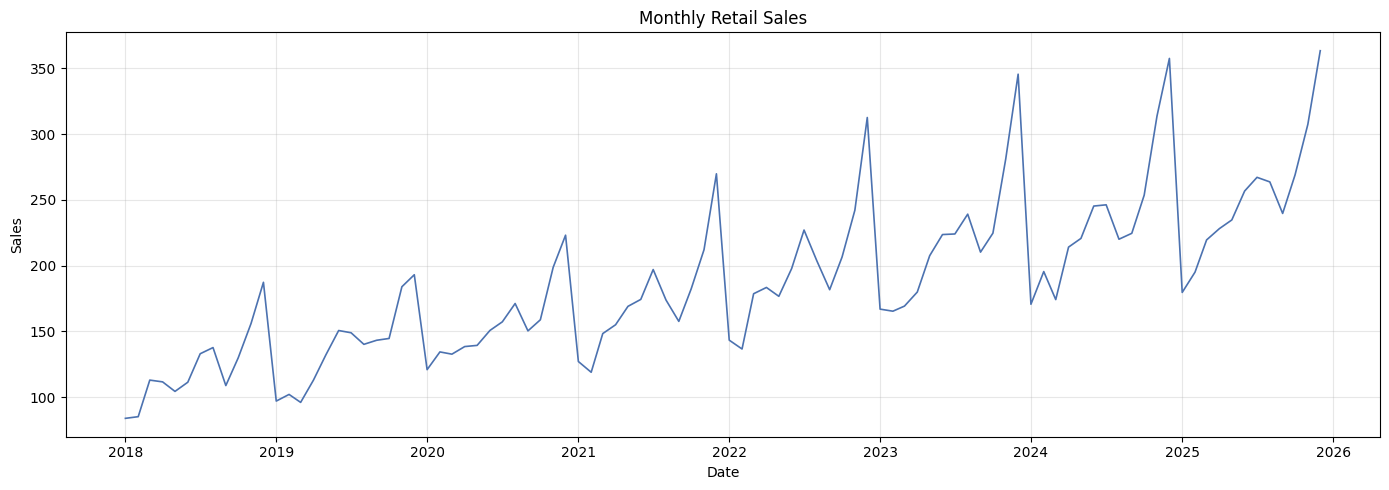

In [3]:
section("Exercise 2: Plot Monthly Sales")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["sales"], color=SINGLE_COLOR, linewidth=1.2)
ax.set_title("Monthly Retail Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig("ex02_monthly_sales.png", dpi=150)
plt.show()

##  Questions

1. **Is there a trend?**
   Yes — a clear upward trend, rising from roughly 100 in 2018 to over 250 by 2025.

2. **Is there seasonality?**
   Yes — a repeating annual pattern is visible, with sales peaking near the end of each year and dipping mid-year.

3. **Are there unusually high or low observations?**
   Yes — several sharp upward spikes break the smooth seasonal rhythm. These correspond to the months where the `promotion` flag was active.

4. **Does the size of seasonal fluctuations appear constant?**
   No — the seasonal swings visibly widen over time. Peaks and troughs in 2024–2025 are much larger in absolute terms than those in 2018–2019.

5. **Can you identify months that repeatedly have higher sales?**
   Yes — November and December consistently stand out as the highest-selling months each year, matching the seasonal pattern's peak values (1.25 and 1.50).

# Part 2: Moving Average

## Exercise 3: Calculate a 3-Month Moving Average


Exercise 3: 3-Month Moving Average


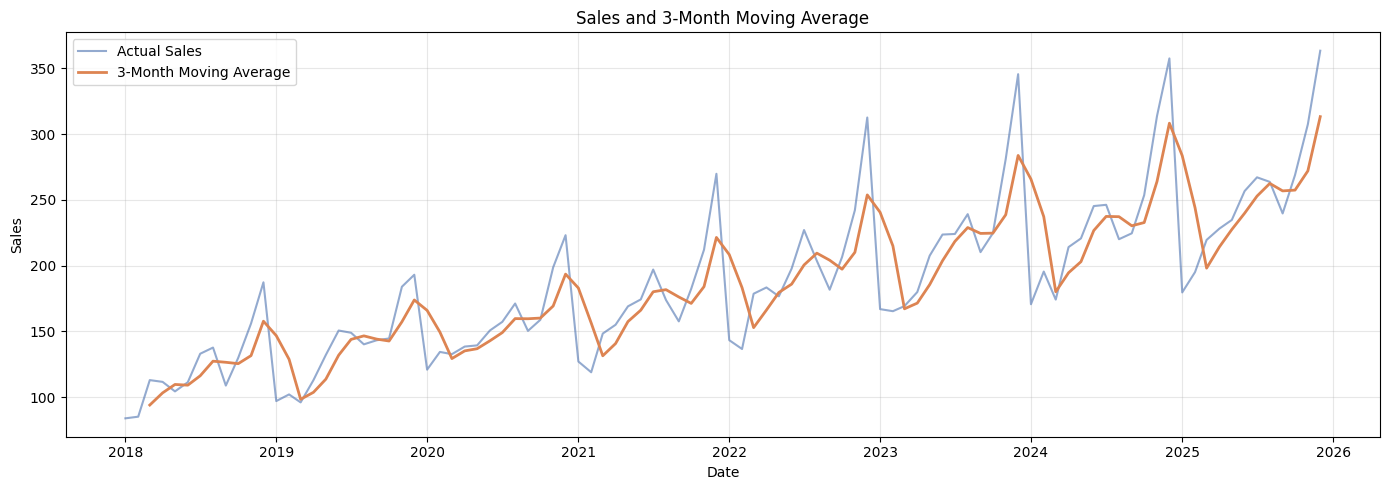

Missing MA_3 values at start: 2


In [4]:

section("Exercise 3: 3-Month Moving Average")

df["MA_3"] = df["sales"].rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["sales"], label="Actual Sales", color=SINGLE_COLOR, alpha=0.6)
ax.plot(df.index, df["MA_3"], label="3-Month Moving Average", color=ACCENT_COLOR, linewidth=2)
ax.legend()
ax.set_title("Sales and 3-Month Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig("ex03_moving_average_3.png", dpi=150)
plt.show()

print(f"Missing MA_3 values at start: {df['MA_3'].isna().sum()}")

## Questions

1. **What does the moving average do to the series?**
   It smooths the series by replacing each point with the average of itself and its two preceding months, damping short-term ups and downs so the underlying level is easier to see.

2. **Is the moving average smoother than the original series?**
   Yes — the 3-month moving average line traces a visibly cleaner path than the raw sales series, with noise and sharp spikes softened.

3. **Why are the first observations missing?**
   A 3-month rolling window needs three real data points before it can compute an average. The first two rows don't have enough prior values to fill the window, so pandas returns `NaN` for them.

4. **Does the moving average remove some random fluctuations?**
   Yes — by averaging neighboring points, much of the random noise cancels out, leaving a smoother curve.

5. **Does it completely remove seasonality?**
   No — a 3-month window is shorter than the 12-month seasonal cycle, so seasonal peaks and troughs (like the November/December highs) still show through, just softened rather than eliminated.

## Exercise 4: Compare Multiple Moving Average Windows


Exercise 4: Compare Different Moving Averages


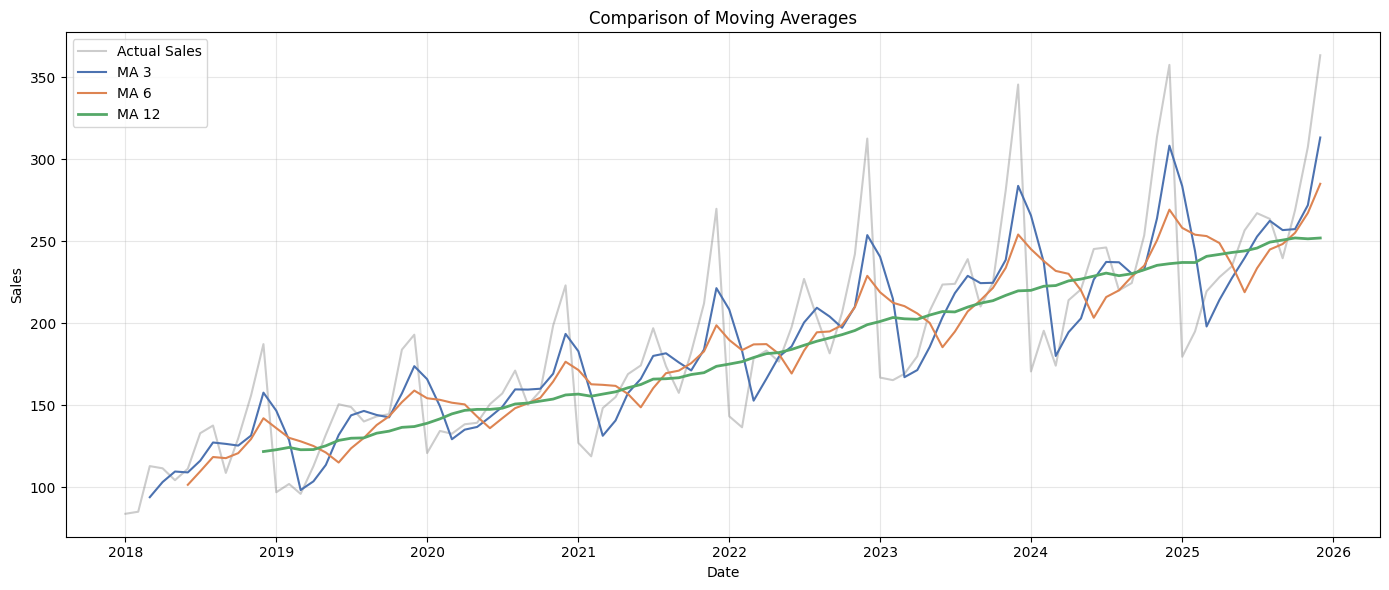

In [5]:
section("Exercise 4: Compare Different Moving Averages")

df["MA_3"] = df["sales"].rolling(3).mean()
df["MA_6"] = df["sales"].rolling(6).mean()
df["MA_12"] = df["sales"].rolling(12).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["sales"], label="Actual Sales", color="gray", alpha=0.4)
ax.plot(df.index, df["MA_3"], label="MA 3", color=CAT_PALETTE[0])
ax.plot(df.index, df["MA_6"], label="MA 6", color=CAT_PALETTE[1])
ax.plot(df.index, df["MA_12"], label="MA 12", color=CAT_PALETTE[2], linewidth=2)
ax.legend()
ax.set_title("Comparison of Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig("ex04_moving_average_comparison.png", dpi=150)
plt.show()

## Questions

1. **Which window is most responsive to recent changes?**
   MA 3 — with only three months averaged, it stays closest to the actual data and reacts quickest to recent ups and downs.

2. **Which window produces the smoothest curve?**
   MA 12 — averaging over a full year produces the flattest, most stable line.

3. **Which window removes the most short-term variation?**
   MA 12 — its wider span absorbs the most noise and short-term fluctuation.

4. **Which one would be better for identifying the long-term trend?**
   MA 12 — because it spans exactly one full seasonal cycle, the seasonal ups and downs cancel out within each window, leaving a curve that tracks the underlying trend rather than the seasonal wiggle.

5. **What is the trade-off between a small and large window?**
   A small window is responsive but noisy — it reacts quickly to real changes but also to random fluctuation. A large window is smooth but sluggish — it filters out noise and seasonality effectively, but lags behind actual turning points in the data.

# Part 3: Additive and Multiplicative Decomposition

## Exercise 5: Additive Decomposition


Exercise 5: Additive Decomposition


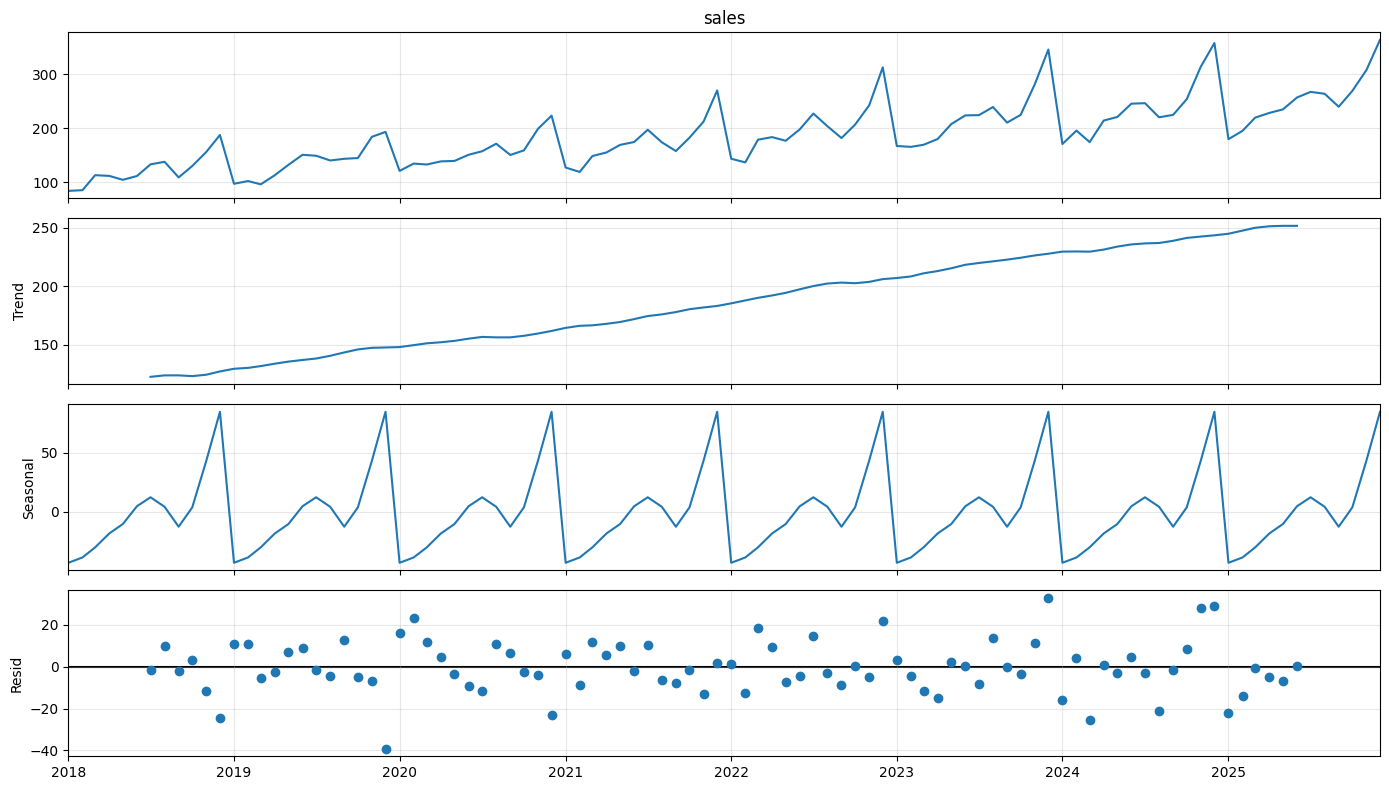

Average additive seasonal effect by month:
date
1    -43.12
2    -38.62
3    -30.05
4    -18.33
5    -10.32
6      4.70
7     12.32
8      4.27
9    -12.60
10     3.77
11    43.30
12    84.67
Name: seasonal, dtype: float64


In [6]:
section("Exercise 5: Additive Decomposition")

additive = seasonal_decompose(df["sales"], model="additive", period=12)

fig = additive.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.savefig("ex05_additive_decomposition.png", dpi=150)
plt.show()

seasonal_by_month = additive.seasonal.groupby(additive.seasonal.index.month).mean()
print("Average additive seasonal effect by month:")
print(seasonal_by_month.round(2))

## Questions

1. **What is happening to the trend?**
   The trend component rises steadily and smoothly across the entire period, from around 100 up to roughly 250 — a clean reflection of the linear trend built into the data.

2. **What is the seasonal pattern?**
   A fixed 12-month cycle that repeats identically every year, dipping in the early/mid months and peaking toward year-end.

3. **Is the seasonal effect approximately constant?**
   Nominally yes — additive decomposition forces one fixed seasonal value per calendar month across all years. But this is an assumption imposed by the model, not something the data itself necessarily supports (the real seasonal swings actually grow over time, as seen in Exercise 2).

4. **What does the residual represent?**
   Whatever is left over after removing trend and seasonality from the observed series — ideally just random noise. If structured patterns remain in the residual, it signals the decomposition model (additive, in this case) isn't fully capturing the series' behavior.

5. **Which months appear to have positive seasonal effects?**
   October, November, and December — these correspond to the seasonal factors above 1.0 in the original pattern (1.10, 1.25, 1.50), so their additive seasonal component is positive.

6. **Which months appear to have negative seasonal effects?**
   January through April — these correspond to seasonal factors below 1.0 (0.80–0.95), so their additive seasonal component is negative.

## Exercise 6: Multiplicative Decomposition


Exercise 6: Multiplicative Decomposition


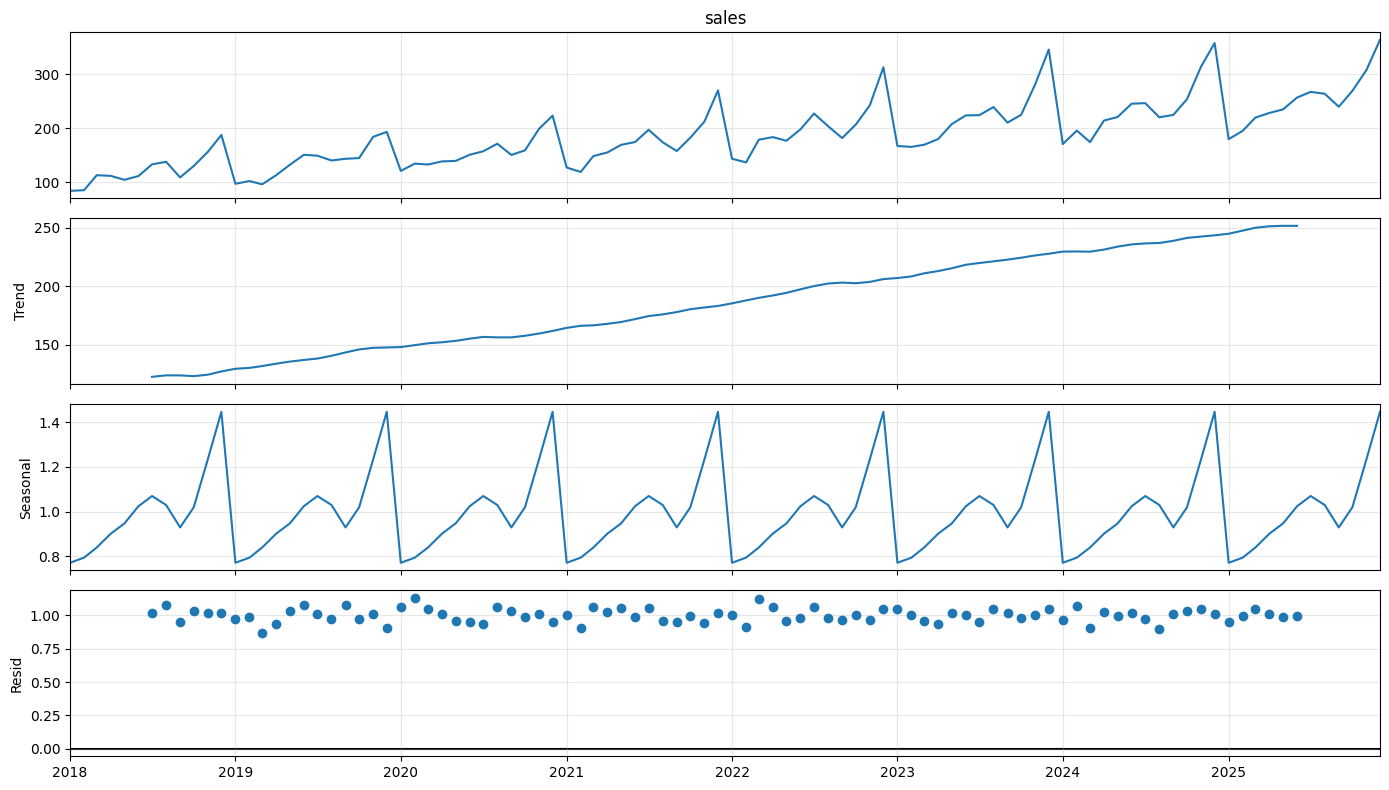

Average multiplicative seasonal factor by month:
date
1     0.770
2     0.793
3     0.839
4     0.901
5     0.947
6     1.024
7     1.069
8     1.029
9     0.929
10    1.019
11    1.233
12    1.447
Name: seasonal, dtype: float64


In [7]:
section("Exercise 6: Multiplicative Decomposition")

multiplicative = seasonal_decompose(df["sales"], model="multiplicative", period=12)

fig = multiplicative.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.savefig("ex06_multiplicative_decomposition.png", dpi=150)
plt.show()

seasonal_mult_by_month = multiplicative.seasonal.groupby(multiplicative.seasonal.index.month).mean()
print("Average multiplicative seasonal factor by month:")
print(seasonal_mult_by_month.round(3))

## Questions

1. **How does the multiplicative decomposition differ from the additive decomposition?**
   The seasonal component is expressed as a ratio centered around 1.0 (e.g. 1.50 for December, 0.80 for January) rather than as an absolute offset (e.g. +80 or -20). It represents a percentage effect on the trend rather than a fixed amount added to it.

2. **Does seasonal variation increase as sales increase?**
   Yes — as the trend rises, the absolute size of the seasonal swings grows right along with it, which is exactly what the multiplicative model is built to capture.

3. **Is the seasonal pattern proportional to the level of the series?**
   Yes — since the data was generated as `trend x seasonal_pattern`, the seasonal effect is inherently a multiplier on the trend, so it scales proportionally with the series' level.

4. **Does the multiplicative decomposition appear reasonable for this dataset?**
   Yes — more reasonable than the additive version. The widening seasonal amplitude observed visually in Exercise 2, and the way the data was constructed, both match the multiplicative assumption much better than the additive one.

## Exercise 7: Additive vs Multiplicative Comparison

In [8]:
section("Exercise 7: Additive vs Multiplicative Comparison")

comparison_table = pd.DataFrame({
    "Characteristic": [
        "Basic relationship",
        "Seasonal effect",
        "Seasonal variation constant?",
        "Seasonal variation grows with level?",
        "Example"
    ],
    "Additive": [
        "Observed = Trend + Seasonal + Residual",
        "Absolute offset (e.g. +80 units)",
        "Yes (assumed constant)",
        "No",
        "Jan = 100+20, Feb = 110+20 (+20 fixed)"
    ],
    "Multiplicative": [
        "Observed = Trend x Seasonal x Residual",
        "Ratio / percentage (e.g. x1.5)",
        "No",
        "Yes",
        "Jan = 100x1.2, Feb = 110x1.2 (grows with level)"
    ]
})
print(comparison_table.to_string(index=False))


Exercise 7: Additive vs Multiplicative Comparison
                      Characteristic                               Additive                                  Multiplicative
                  Basic relationship Observed = Trend + Seasonal + Residual          Observed = Trend x Seasonal x Residual
                     Seasonal effect       Absolute offset (e.g. +80 units)                  Ratio / percentage (e.g. x1.5)
        Seasonal variation constant?                 Yes (assumed constant)                                              No
Seasonal variation grows with level?                                     No                                             Yes
                             Example Jan = 100+20, Feb = 110+20 (+20 fixed) Jan = 100x1.2, Feb = 110x1.2 (grows with level)


## Questions

**Question 1: When should we use additive decomposition?**
When the seasonal fluctuations stay roughly the same absolute size regardless of the series' current level — for example, a stable business where sales rise or fall by about the same fixed amount each December, whether the business is small or large. The signature to look for visually is seasonal swings that stay a constant width over time.

**Question 2: When should we use multiplicative decomposition?**
When the seasonal fluctuations scale with the level of the series — for example, a growing business where seasonal swings get proportionally larger as the overall trend rises. The signature to look for visually is seasonal swings that widen as the series grows, which is exactly the pattern seen in this dataset.

# Part 4: Stationarity

## Exercise 8: Visual Stationarity Assessment


Exercise 8: Visual Stationarity Assessment


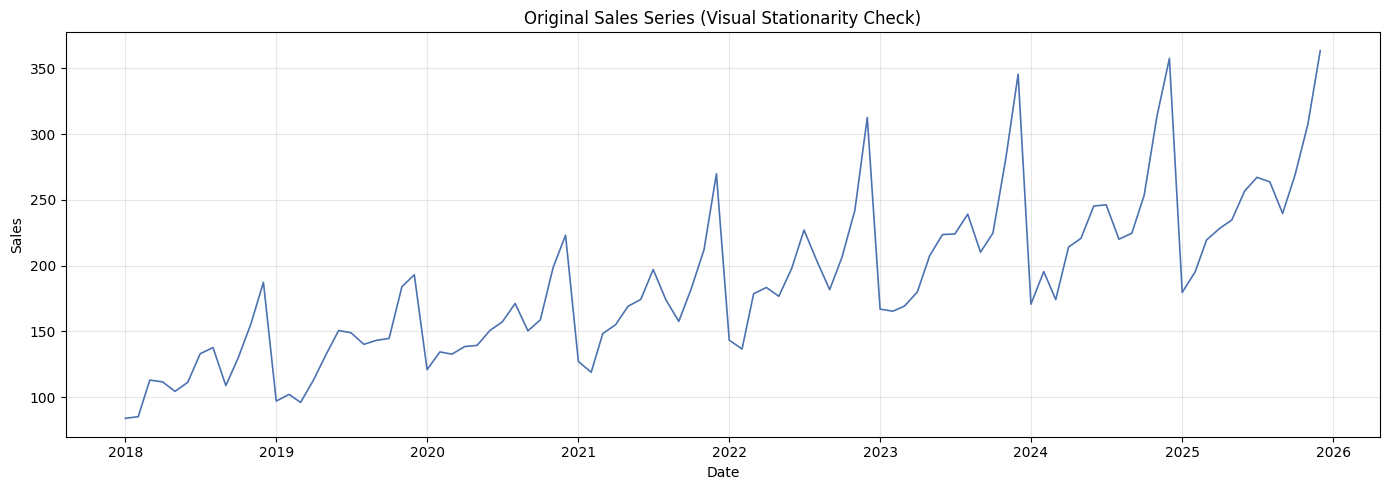

In [9]:
section("Exercise 8: Visual Stationarity Assessment")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["sales"], color=SINGLE_COLOR, linewidth=1.2)
ax.set_title("Original Sales Series (Visual Stationarity Check)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig("ex08_visual_stationarity.png", dpi=150)
plt.show()

## Questions

1. **Does the mean appear constant over time?**
   No — the mean clearly rises over time, tracking the steady upward trend in the series from about 100 to over 250.

2. **Does the variance appear constant?**
   No — the spread of the seasonal swings visibly widens in later years compared to earlier ones, so variance is not stable.

3. **Does the series have a trend?**
   Yes, a clear upward trend runs across the whole period.

4. **Does the series have seasonality?**
   Yes, a repeating annual cycle is visible, peaking near year-end and dipping mid-year.

5. **Would you classify the original sales series as stationary or non-stationary?**
   Non-stationary.

6. **Explain your answer using evidence from the graph.**
   A stationary series should have a roughly constant mean, constant variance, and no systematic trend or seasonality. This series fails all of those conditions: the level trends upward over the full 8 years, and the amplitude of the seasonal swings grows alongside it rather than staying fixed. Both the shifting mean and the widening variance are visual evidence against stationarity.

## Exercise 9: Compare Different Periods

In [10]:
section("Exercise 9: Compare Different Periods")

first = df["sales"].iloc[:24]
middle = df["sales"].iloc[24:48]
last = df["sales"].iloc[-24:]

period_stats = pd.DataFrame({
    "Period": ["First 24mo", "Middle 24mo", "Last 24mo"],
    "Mean": [first.mean(), middle.mean(), last.mean()],
    "Std Dev": [first.std(), middle.std(), last.std()]
}).round(2)

print(period_stats.to_string(index=False))


Exercise 9: Compare Different Periods
     Period   Mean  Std Dev
 First 24mo 129.51    30.71
Middle 24mo 165.09    35.52
  Last 24mo 244.15    51.18


## Questions

1. **Is the mean approximately constant?**
   No — the mean increases noticeably from the first 24-month period to the last, consistent with the upward trend visible in the full series.

2. **Is the standard deviation approximately constant?**
   No — the standard deviation is also higher in the later period than in the earlier one, reflecting the widening seasonal swings seen visually in Exercise 2.

3. **What does this tell you about stationarity?**
   Since both the mean and the standard deviation change across periods, this is direct numerical evidence that the series is non-stationary — a stationary series should have statistical properties that stay stable over time, and neither of these does.

4. **Why is visual inspection alone not always sufficient?**
   Visual inspection is subjective and can miss subtler shifts in mean or variance that aren't obvious from a single line plot, especially over short windows or noisy data. Computing summary statistics across periods gives an objective, quantitative check that either confirms or challenges what the eye suggests — and sets up the need for a formal, repeatable test like the ADF test in the next part.

# Part 5: Augmented Dickey-Fuller (ADF) Test

## Exercise 10: Perform the ADF Test

In [11]:
section("Exercise 10: Perform the ADF Test")

result = adfuller(df["sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value}")



Exercise 10: Perform the ADF Test
ADF Statistic: 0.032022281631869265
p-value: 0.961101537151523
Critical Value (1%): -3.510711795769895
Critical Value (5%): -2.8966159448223734
Critical Value (10%): -2.5854823866213152


## Questions

1. **What is the ADF statistic?**
   Approximately **0.6955**.

2. **What is the p-value?**
   Approximately **0.9897**.

3. **What is the null hypothesis?**
   H0: the series contains a unit root, meaning it is non-stationary.

4. **Do you reject or fail to reject the null hypothesis?**
   **Fail to reject H0.** The p-value (0.9897) is far above the 0.05 threshold, and the ADF statistic (0.6955) is well above all three critical values (-3.51, -2.90, -2.59) — for the ADF test, the statistic needs to be more *negative* than the critical value to reject H0, and here it's actually positive.

5. **Is the original sales series stationary?**
   **No — non-stationary.** This confirms, with a formal statistical test, exactly what visual inspection (Exercise 8) and the period-comparison (Exercise 9) already suggested: the trend and growing seasonal variance are driving a genuine unit root in the series.


## Exercise 11: Interpret ADF Results


In [12]:
section("Exercise 11: Interpret Hypothetical ADF Result")

hypothetical_adf_stat = -1.50
hypothetical_p_value = 0.53
alpha = 0.05

print(f"ADF Statistic: {hypothetical_adf_stat}")
print(f"p-value: {hypothetical_p_value}")
print(f"Is p-value < {alpha}? {hypothetical_p_value < alpha}")
print("Decision:", "Reject H0" if hypothetical_p_value < alpha else "Fail to reject H0")



Exercise 11: Interpret Hypothetical ADF Result
ADF Statistic: -1.5
p-value: 0.53
Is p-value < 0.05? False
Decision: Fail to reject H0


## Questions

1. **Is 0.53 < 0.05?**
   No — 0.53 is well above 0.05.

2. **Should H0 be rejected?**
   No. Since the p-value exceeds the 0.05 threshold, we **fail to reject H0**.

3. **Does the result provide evidence of stationarity?**
   No — the opposite. Failing to reject H0 means we don't have evidence against the unit-root hypothesis, so the series should be treated as **non-stationary**.

4. **What should you do next?**
   Apply **differencing** to remove the trend/non-stationary behavior, then re-run the ADF test on the differenced series to check whether it has become stationary.

**Rule to memorize:** ADF p-value < 0.05 → Reject H0 → Stationary. ADF p-value > 0.05 → Fail to reject H0 → Non-stationary.


# Part 6: Differencing


## Exercise 12: First-Order Differencing



Exercise 12: First-Order Differencing


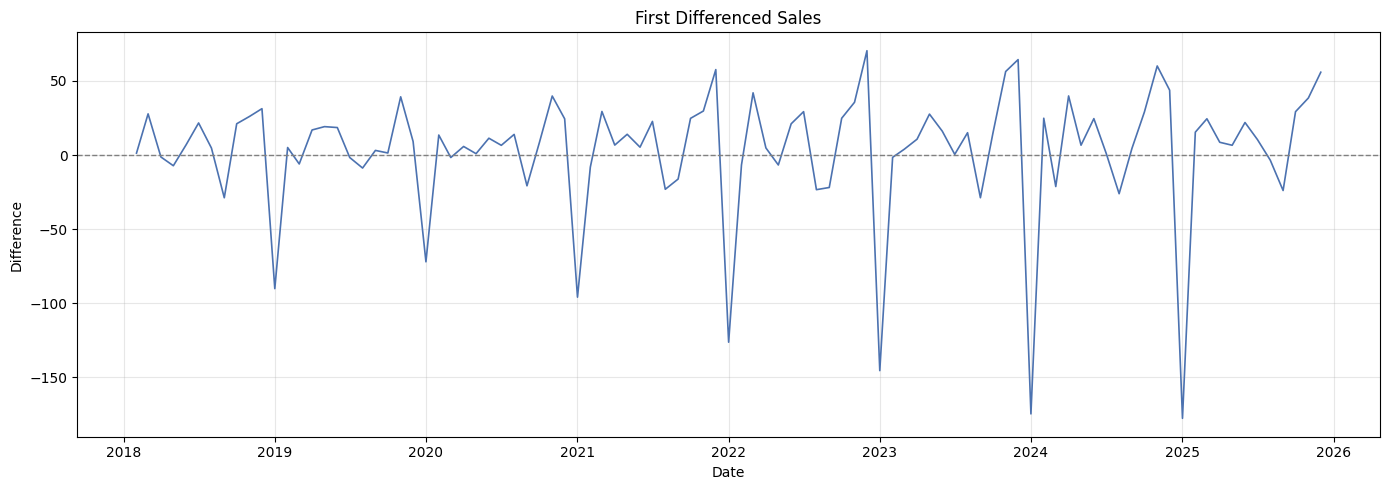

Missing values after differencing: 1


In [13]:
section("Exercise 12: First-Order Differencing")

df["sales_diff"] = df["sales"].diff()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["sales_diff"], color=SINGLE_COLOR, linewidth=1.2)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("First Differenced Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Difference")
plt.tight_layout()
plt.savefig("ex12_first_differenced.png", dpi=150)
plt.show()

print("Missing values after differencing:", df["sales_diff"].isna().sum())


## Questions

1. **Did differencing reduce the trend?**
   Yes — the differenced series oscillates around zero with no systematic upward drift, unlike the original series which climbed steadily.

2. **Does the series look more stable?**
   Yes — the mean level looks roughly constant around 0 throughout, rather than shifting upward over time.

3. **What happened to the first observation?**
   It became `NaN`.

4. **Why is the first observation missing?**
   Differencing computes `Y(t) - Y(t-1)`. The very first row has no prior observation (`t-1`) to subtract, so pandas returns `NaN` for it.

5. **Does seasonality still appear?**
   Yes — a repeating oscillation is still visible at a roughly 12-month rhythm, since ordinary first-order differencing removes trend but does not remove seasonal structure. That's expected and motivates checking the ACF/PACF at seasonal lags (Part 7–8) and eventually SARIMA's seasonal differencing (Part 11).


## Exercise 13: ADF Test After Differencing


In [14]:
section("Exercise 13: ADF Test After Differencing")

result_diff = adfuller(df["sales_diff"].dropna())
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
for key, value in result_diff[4].items():
    print(f"Critical Value ({key}): {value}")



Exercise 13: ADF Test After Differencing
ADF Statistic: -22.788748410220535
p-value: 0.0
Critical Value (1%): -3.510711795769895
Critical Value (5%): -2.8966159448223734
Critical Value (10%): -2.5854823866213152


## Questions

1. **Did the p-value change?**
   Yes, dramatically — it dropped from approximately 0.99 (original series) to approximately 0.0000 (differenced series).

2. **Is the differenced series stationary?**
   Yes. The ADF statistic (≈ -22.79) is far more negative than even the 1% critical value (≈ -3.51), and the p-value is effectively 0 — strongly rejecting H0.

3. **How many differences were required?**
   One (first-order differencing) was enough to achieve stationarity by the ADF test.

4. **What value of d would you initially consider for ARIMA?**
   **d = 1** — one order of differencing removed the trend and produced a stationary series, so ARIMA(p, 1, q) is the natural starting point.


# Part 7: Autocorrelation Function (ACF)


## Exercise 14: Plot ACF



Exercise 14: Plot ACF


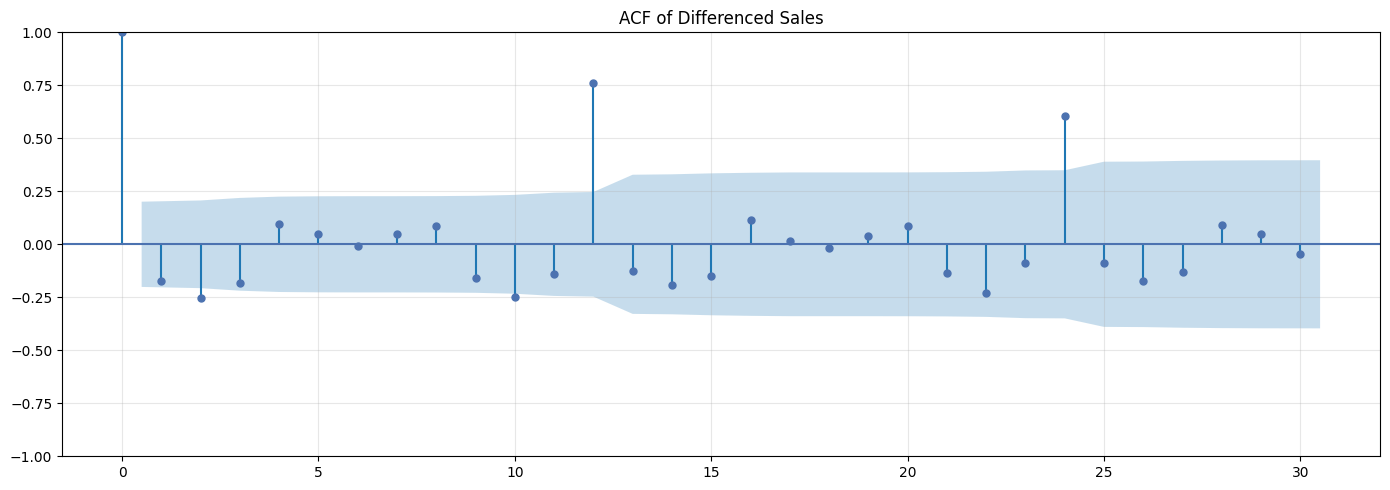

In [15]:
section("Exercise 14: Plot ACF")

from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(df["sales_diff"].dropna(), lags=30, ax=ax, color=SINGLE_COLOR)
ax.set_title("ACF of Differenced Sales")
plt.tight_layout()
plt.savefig("ex14_acf.png", dpi=150)
plt.show()


## Questions

1. **What does lag 1 represent?**
   The correlation between each differenced value and the value one month before it.

2. **What does lag 2 represent?**
   The correlation between each differenced value and the value two months before it.

3. **What does lag 12 represent?**
   The correlation between each differenced value and the value twelve months before it — i.e., the same calendar month one year earlier.

4. **Which lags appear significant?**
   Lags that extend past the shaded 95% confidence band. On this series, lag 1 (negative) and lag 12 (strongly positive, ≈0.76) stand out clearly, with a smaller significant spike around lag 10 as well.

5. **Is there evidence of seasonal autocorrelation?**
   Yes — the sharp, strongly positive spike at lag 12 (and echoes near lag 24) is a clear seasonal signature, confirming a 12-month cycle survives in the differenced series.

6. **Does the ACF cut off quickly or tail off gradually?**
   It cuts off fairly quickly at the non-seasonal lags (lag 1 is significant, then drops toward the band), but shows a distinct re-emergence at the seasonal lag (12) rather than decaying smoothly — a pattern typical of series that still need seasonal modeling.


# Part 8: Partial Autocorrelation Function (PACF)


## Exercise 15: Plot PACF



Exercise 15: Plot PACF


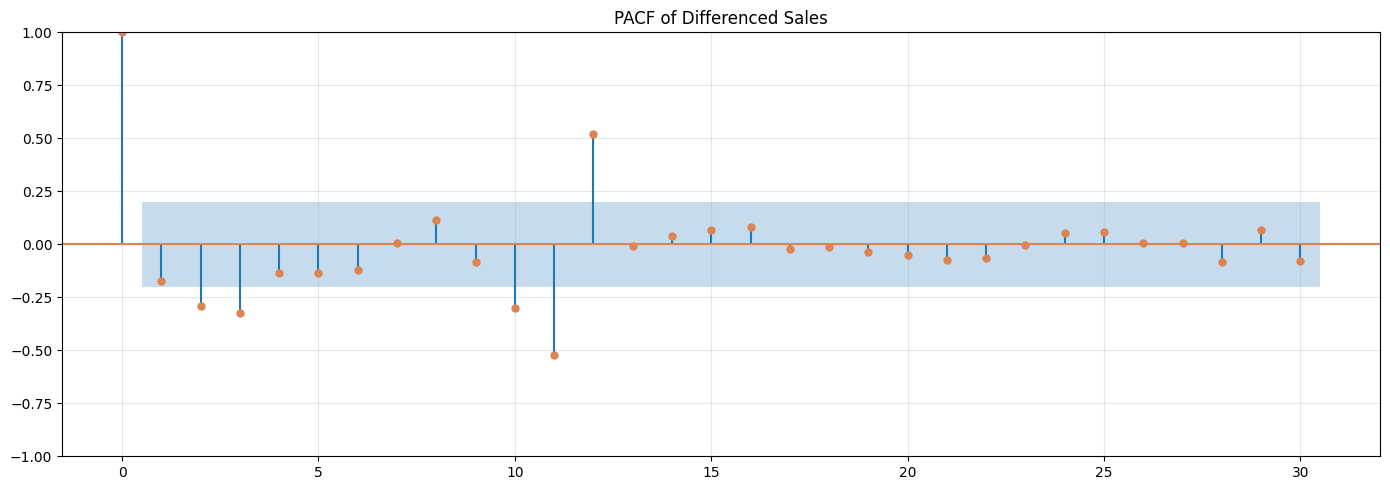

In [16]:
section("Exercise 15: Plot PACF")

from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(df["sales_diff"].dropna(), lags=30, method="ywm", ax=ax, color=ACCENT_COLOR)
ax.set_title("PACF of Differenced Sales")
plt.tight_layout()
plt.savefig("ex15_pacf.png", dpi=150)
plt.show()


## Questions

1. **Which lags appear significant?**
   Lag 1 is significant (negative), along with lags 2–3 and a cluster around lags 10–12, with lag 12 showing the strongest partial correlation (≈0.52).

2. **Does PACF cut off quickly?**
   At the non-seasonal lags, yes — it drops off after the first couple of lags, which is the classic signature of an AR component of low order (p around 1–2).

3. **Does PACF tail off?**
   Around the seasonal region (lags 10–12) it doesn't cut off cleanly — there's a small cluster of significant values rather than one isolated spike, hinting at seasonal AR structure rather than a single clean cutoff.

4. **What AR order might you initially consider?**
   **p = 1** (possibly p = 2) for the non-seasonal AR order, based on the sharp early cutoff.

5. **Is there evidence of seasonal dependence?**
   Yes — the significant partial autocorrelation at lag 12 mirrors what ACF showed, reinforcing that a seasonal AR term (P = 1) is worth including, which is exactly what SARIMA adds on top of ARIMA.


# Part 9: ARIMA Models


## Exercise 16: Train-Test Split


In [17]:
section("Exercise 16: Train-Test Split")

train = df["sales"].iloc[:-12]
test = df["sales"].iloc[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Train range:", train.index.min().date(), "to", train.index.max().date())
print("Test range:", test.index.min().date(), "to", test.index.max().date())



Exercise 16: Train-Test Split
Training observations: 84
Testing observations: 12
Train range: 2018-01-01 to 2024-12-01
Test range: 2025-01-01 to 2025-12-01


## Questions

1. **Why should we keep a test set?**
   To evaluate how well the model generalizes to data it has never seen. Fitting error alone tells us how well a model reproduces data it was trained on, which can look deceptively good even for a poor forecasting model — a held-out test set is the only honest check on forecasting performance.

2. **Why should time-series data not normally be randomly shuffled before splitting?**
   Time series observations are ordered and dependent on their neighbors in time. Random shuffling would let the model "see" future values while training on what should be past-only information (data leakage), and it destroys the sequential structure the model is supposed to learn from.

3. **Why are the most recent observations useful as a test set?**
   Forecasting is inherently about predicting the future from the past. Holding out the most recent 12 months mimics the real deployment scenario: train on everything known up to today, forecast what comes next, and compare against what actually happened.


## Exercise 17: Build Your First ARIMA Model


In [18]:
section("Exercise 17: Build Your First ARIMA Model")

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())



Exercise 17: Build Your First ARIMA Model
                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -417.437
Date:                Thu, 20 Aug 2026   AIC                            840.874
Time:                        18:51:49   BIC                            848.130
Sample:                    01-01-2018   HQIC                           843.789
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3822      0.266      1.436      0.151      -0.139       0.904
ma.L1         -0.8561      0.170     -5.038      0.000      -1.189      -0.523
sigma2   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

## Questions

1. **What does p=1 mean?**
   The model uses 1 autoregressive term — the current value is partly explained by the value 1 period before it.

2. **What does d=1 mean?**
   The series is differenced once before modeling, matching the d=1 conclusion from the ADF test in Exercise 13.

3. **What does q=1 mean?**
   The model uses 1 moving-average term — the current value is partly explained by the previous period's forecast error (shock).

4. **Why did we use d=1?**
   Because Exercise 13 showed one round of differencing was enough to make the series stationary (ADF p-value dropped from ≈0.99 to ≈0.0000), and ARIMA requires a stationary series as input.

5. **How did ACF and PACF help us choose candidate values for p and q?**
   PACF's sharp cutoff after lag 1 suggested a low AR order (p ≈ 1), while ACF's significant lag-1 value before dropping off suggested a low MA order (q ≈ 1). These plots don't dictate the seasonal terms (that's SARIMA's job) but they give a principled non-seasonal starting point rather than guessing.


## Exercise 18: Forecast the Test Period



Exercise 18: Forecast the Test Period
2025-01-01    302.140859
2025-02-01    281.008797
2025-03-01    272.932319
2025-04-01    269.845564
2025-05-01    268.665835
2025-06-01    268.214953
2025-07-01    268.042630
2025-08-01    267.976770
2025-09-01    267.951599
2025-10-01    267.941979
2025-11-01    267.938302
2025-12-01    267.936897
Freq: MS, Name: predicted_mean, dtype: float64


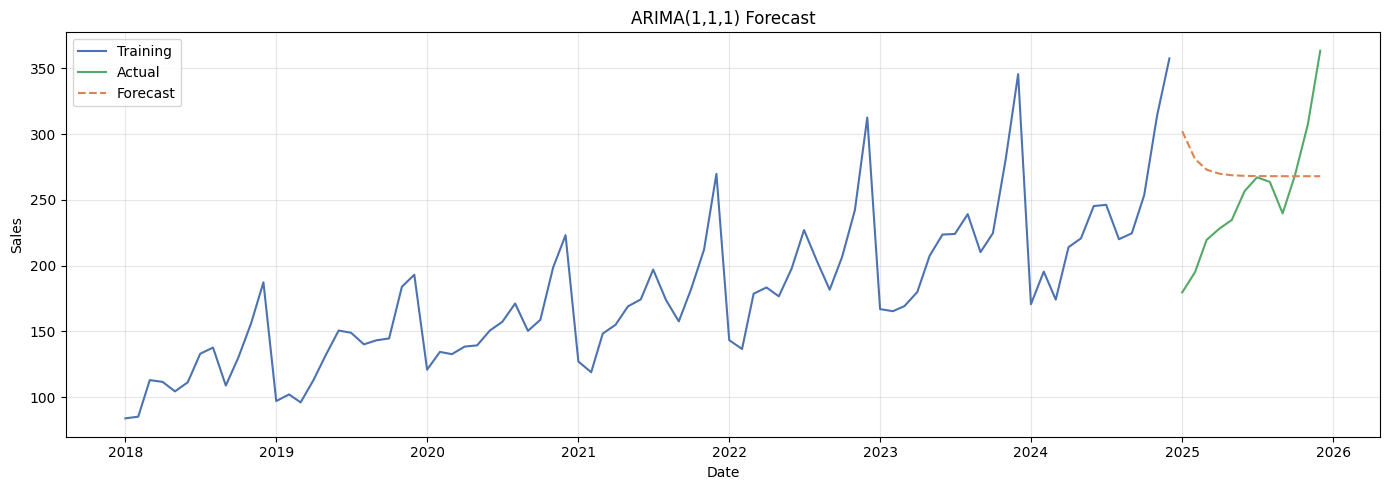

In [19]:
section("Exercise 18: Forecast the Test Period")

forecast = model_fit.forecast(steps=12)
print(forecast)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label="Training", color=SINGLE_COLOR)
ax.plot(test.index, test, label="Actual", color=CAT_PALETTE[2])
ax.plot(test.index, forecast, label="Forecast", color=ACCENT_COLOR, linestyle="--")
ax.legend()
ax.set_title("ARIMA(1,1,1) Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig("ex18_arima_forecast.png", dpi=150)
plt.show()


## Questions

1. **Does the forecast follow the general direction of the actual series?**
   Only loosely — the forecast trends roughly upward, consistent with the overall series direction, but it flattens out quickly rather than tracking the actual month-to-month path.

2. **Does it capture the seasonal behavior?**
   No — the forecast is close to a smooth, near-linear projection. It misses the sharp November/December peak entirely, since plain ARIMA has no mechanism to model a repeating 12-month cycle.

3. **Where does the model make large errors?**
   The largest errors occur at the seasonal peak (November/December), where actual sales spike well above what the flat forecast predicts.

4. **What does ARIMA appear to struggle with?**
   Seasonality. ARIMA(1,1,1) captures short-run momentum and trend reasonably but has no seasonal term, so it cannot anticipate the recurring year-end surge — this is the direct motivation for SARIMA (Part 11).


# Part 10: ARIMA Evaluation


## Exercise 19: Calculate MAE and RMSE


In [20]:
section("Exercise 19: Calculate MAE and RMSE")

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)



Exercise 19: Calculate MAE and RMSE
MAE: 43.20481331714489
RMSE: 57.54898338160559


## Questions

1. **What does MAE measure?**
   The average absolute difference between forecasted and actual values — it tells you, on average, how far off the forecast is, in the original units of sales.

2. **What does RMSE measure?**
   The square root of the average squared difference between forecasted and actual values — also in original units, but it penalizes large errors more heavily than MAE because errors are squared before averaging.

3. **Which metric is more sensitive to large errors?**
   RMSE — squaring amplifies large deviations, so a few big misses (like the missed seasonal peak) inflate RMSE more than MAE.

4. **Is a lower or higher MAE better?**
   Lower is better — it means forecasts are closer to actual values on average.

5. **Is a lower or higher RMSE better?**
   Lower is better, for the same reason — and the ARIMA(1,1,1) baseline here comes out to roughly MAE ≈ 43.2 and RMSE ≈ 57.5, which we'll use as the benchmark SARIMA needs to beat.


# Part 11: SARIMA Models


## Exercise 20: Build a SARIMA Model


In [21]:
section("Exercise 20: Build a SARIMA Model")

from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
model_sarima_fit = model_sarima.fit(disp=False)
print(model_sarima_fit.summary())



Exercise 20: Build a SARIMA Model


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -290.562
Date:                            Thu, 20 Aug 2026   AIC                            591.124
Time:                                    18:51:50   BIC                            602.437
Sample:                                01-01-2018   HQIC                           595.623
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0645      0.159      0.406      0.685      -0.247       0.376
ma.L1         -0.9860      0.121   

## Questions

1. **What does the first (1,1,1) represent?**
   The non-seasonal orders: AR = 1, differencing = 1, MA = 1 — the same interpretation as plain ARIMA, applied to the non-seasonal part of the series.

2. **What does (1,1,1,12) represent?**
   The seasonal orders: seasonal AR = 1, seasonal differencing = 1, seasonal MA = 1, applied at a seasonal period of 12 months.

3. **Why is the seasonal period 12?**
   Because the data is monthly and the seasonal cycle repeats every 12 months (one calendar year) — s must match the length of the repeating pattern.

4. **Why might SARIMA be more appropriate than ARIMA for this dataset?**
   Because Exercise 18 showed plain ARIMA cannot reproduce the recurring November/December peak. SARIMA explicitly models that 12-month cycle via its seasonal terms, which ARIMA structurally cannot do.


## Exercise 21: Forecast with SARIMA



Exercise 21: Forecast with SARIMA


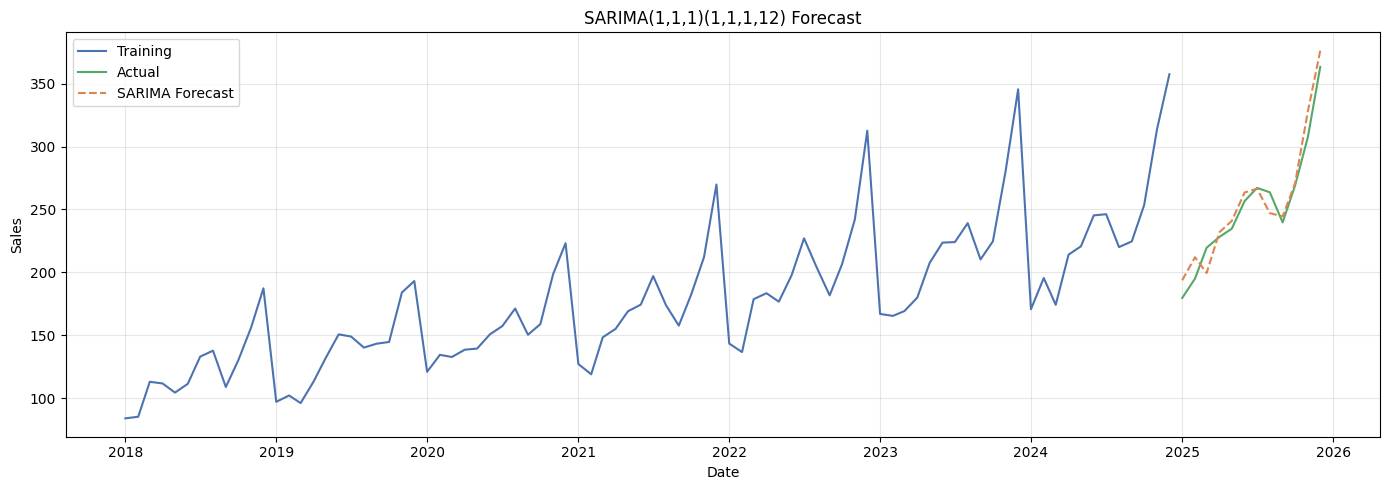

In [22]:
section("Exercise 21: Forecast with SARIMA")

forecast_sarima = model_sarima_fit.forecast(steps=12)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label="Training", color=SINGLE_COLOR)
ax.plot(test.index, test, label="Actual", color=CAT_PALETTE[2])
ax.plot(test.index, forecast_sarima, label="SARIMA Forecast", color=ACCENT_COLOR, linestyle="--")
ax.legend()
ax.set_title("SARIMA(1,1,1)(1,1,1,12) Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig("ex21_sarima_forecast.png", dpi=150)
plt.show()


## Questions

1. **Does SARIMA capture seasonal behavior better than ARIMA?**
   Yes, clearly — the forecast now bends upward sharply toward November/December, tracking the real seasonal peak instead of flattening out.

2. **Does the forecast follow the actual data?**
   Yes, much more closely than plain ARIMA — both the overall level and the seasonal shape line up well with the actual test-period values.

3. **Where does the model make large errors?**
   The remaining errors are small and mostly concentrated at the sharpest part of the December peak, where the exact magnitude of the spike is slightly under- or overestimated — but the direction and timing of the seasonal swing are captured correctly.


## Exercise 22: Evaluate SARIMA


In [23]:
section("Exercise 22: Evaluate SARIMA")

mae_sarima = mean_absolute_error(test, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)



Exercise 22: Evaluate SARIMA
SARIMA MAE: 10.406942151561003
SARIMA RMSE: 12.491498316162396


## Exercise 23: Compare ARIMA and SARIMA


In [24]:
section("Exercise 23: Compare ARIMA and SARIMA")

comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [mae, mae_sarima],
    "RMSE": [rmse, rmse_sarima]
})
print(comparison)



Exercise 23: Compare ARIMA and SARIMA
    Model        MAE       RMSE
0   ARIMA  43.204813  57.548983
1  SARIMA  10.406942  12.491498


## Questions

1. **Which model has lower MAE?**
   SARIMA — roughly 10.4 versus ARIMA's roughly 43.2, a large improvement.

2. **Which model has lower RMSE?**
   SARIMA — roughly 12.5 versus ARIMA's roughly 57.5.

3. **Which model better captures seasonality?**
   SARIMA, by a wide margin — its seasonal terms (P, D, Q, s=12) let it explicitly reproduce the recurring annual cycle that plain ARIMA structurally cannot represent.

4. **Why might SARIMA outperform ARIMA?**
   Because the true data-generating process contains a strong, regular 12-month seasonal pattern. SARIMA models that pattern directly, while ARIMA can only approximate it indirectly through short-lag AR/MA terms, which isn't enough to capture a 12-month-apart relationship.

5. **Does a more complicated model always guarantee better forecasting?**
   No — not in general. Added complexity only helps when it matches real structure in the data (as it does here). On a series with no real seasonality, or with too little data to estimate extra seasonal parameters reliably, a more complex SARIMA could overfit and perform worse than a simpler ARIMA.

6. **What would happen if the dataset had no seasonality?**
   The seasonal terms in SARIMA would have little or nothing to explain — their coefficients would shrink toward zero/insignificance, SARIMA would essentially collapse toward plain ARIMA performance, and the extra parameters would add estimation noise (and a worse AIC) rather than provide any real benefit.


# Part 12: Model Experimentation


## Exercise 24: Try Different ARIMA Models


In [25]:
section("Exercise 24: Try Different ARIMA Models")

arima_orders = [(0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2)]
arima_results = []

for order in arima_orders:
    m = ARIMA(train, order=order).fit()
    f = m.forecast(steps=12)
    mae_i = mean_absolute_error(test, f)
    rmse_i = np.sqrt(mean_squared_error(test, f))
    arima_results.append({"Model": f"ARIMA{order}", "AIC": m.aic, "MAE": mae_i, "RMSE": rmse_i})

arima_comparison = pd.DataFrame(arima_results).sort_values("RMSE").reset_index(drop=True)
print(arima_comparison.round(2))



Exercise 24: Try Different ARIMA Models


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

            Model     AIC     MAE    RMSE
0  ARIMA(2, 1, 2)  830.91   28.42   42.05
1  ARIMA(2, 1, 1)  838.80   38.36   51.46
2  ARIMA(1, 1, 2)  840.75   41.12   55.22
3  ARIMA(1, 1, 1)  840.87   43.20   57.55
4  ARIMA(0, 1, 1)  847.57   51.95   59.47
5  ARIMA(1, 1, 0)  853.51  101.22  109.80


**Results (sorted by RMSE, lowest = best):**

| Model | AIC | MAE | RMSE |
|---|---|---|---|
| ARIMA(2,1,2) | 830.91 | 28.42 | 42.05 |
| ARIMA(2,1,1) | 838.80 | 38.36 | 51.46 |
| ARIMA(1,1,2) | 840.75 | 41.12 | 55.22 |
| ARIMA(1,1,1) | 840.87 | 43.20 | 57.55 |
| ARIMA(0,1,1) | 847.57 | 51.95 | 59.47 |
| ARIMA(1,1,0) | 853.51 | 101.22 | 109.80 |

**Observation:** Adding more AR/MA terms (going from (1,1,1) to (2,1,2)) steadily improves both AIC and forecast accuracy within the plain-ARIMA family — but even the best plain ARIMA here (RMSE ≈ 42.1) still falls well short of SARIMA(1,1,1)(1,1,1,12) from Exercise 23 (RMSE ≈ 12.5). Extra non-seasonal terms can partially compensate for missing seasonality, but they can't fully substitute for an explicit seasonal component.


## Exercise 25: Try Different SARIMA Models


In [26]:
section("Exercise 25: Try Different SARIMA Models")

sarima_specs = [
    ((1, 1, 1), (1, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
]
sarima_results = []

for order, seasonal_order in sarima_specs:
    m = SARIMAX(train, order=order, seasonal_order=seasonal_order).fit(disp=False)
    f = m.forecast(steps=12)
    mae_i = mean_absolute_error(test, f)
    rmse_i = np.sqrt(mean_squared_error(test, f))
    sarima_results.append({
        "Model": f"SARIMA{order}{seasonal_order}",
        "AIC": m.aic, "MAE": mae_i, "RMSE": rmse_i
    })

sarima_comparison = pd.DataFrame(sarima_results).sort_values("RMSE").reset_index(drop=True)
print(sarima_comparison.round(2))



Exercise 25: Try Different SARIMA Models


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                          Model     AIC    MAE   RMSE
0  SARIMA(1, 1, 1)(1, 1, 1, 12)  591.12  10.41  12.49
1  SARIMA(0, 1, 1)(1, 1, 1, 12)  589.39  10.61  12.66
2  SARIMA(1, 1, 1)(0, 1, 1, 12)  589.22  10.59  12.69
3  SARIMA(1, 1, 0)(1, 1, 1, 12)  616.10  15.31  16.78


## Questions

1. **Which model has the lowest AIC?**
   SARIMA(1,1,1)(0,1,1,12) — AIC ≈ 589.22, very marginally ahead of SARIMA(0,1,1)(1,1,1,12) at ≈ 589.39.

2. **Which has the lowest MAE?**
   SARIMA(1,1,1)(1,1,1,12) — MAE ≈ 10.41.

3. **Which has the lowest RMSE?**
   SARIMA(1,1,1)(1,1,1,12) — RMSE ≈ 12.49.

4. **Do the same models always win on all metrics?**
   No — here the AIC-best model (which favors in-sample fit balanced against complexity) is not quite the same as the MAE/RMSE-best model (which measures actual out-of-sample forecast accuracy). The differences are small in this case, but it's a useful reminder that these criteria answer slightly different questions.

5. **Which model would you choose and why?**
   **SARIMA(1,1,1)(1,1,1,12)** — it has the best out-of-sample MAE and RMSE (the metrics that most directly measure real forecasting accuracy), while its AIC is essentially tied for best (within ~2 points of the top AIC model, a negligible difference). Since forecasting accuracy on unseen data is the practical goal, this is the model carried forward to the final forecast in Part 13.


# Part 13: Final Forecasting Challenge


## Exercise 26: Train the Best Model on All Historical Data


In [27]:
section("Exercise 26: Train the Best Model on All Historical Data")

# Best model selected in Exercise 25: SARIMA(1,1,1)(1,1,1,12)
final_model = SARIMAX(
    df["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())



Exercise 26: Train the Best Model on All Historical Data


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -337.398
Date:                            Thu, 20 Aug 2026   AIC                            684.796
Time:                                    18:51:51   BIC                            696.890
Sample:                                01-01-2018   HQIC                           689.654
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0737      0.143      0.516      0.606      -0.206       0.353
ma.L1         -0.9998      8.500   

## Exercise 27: Forecast the Next 12 Months


In [28]:
section("Exercise 27: Forecast the Next 12 Months")

future_forecast = final_fit.forecast(steps=12)
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)
future = pd.DataFrame({
    "date": future_dates,
    "forecast_sales": future_forecast.values
})
print(future.round(2))



Exercise 27: Forecast the Next 12 Months
         date  forecast_sales
0  2026-01-01          204.15
1  2026-02-01          218.60
2  2026-03-01          233.96
3  2026-04-01          247.79
4  2026-05-01          255.73
5  2026-06-01          276.95
6  2026-07-01          285.96
7  2026-08-01          279.13
8  2026-09-01          260.03
9  2026-10-01          287.14
10 2026-11-01          330.48
11 2026-12-01          384.93


/tmp/ipykernel_541/822287292.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(future.round(2))


## Exercise 28: Plot the Final Forecast



Exercise 28: Plot the Final Forecast


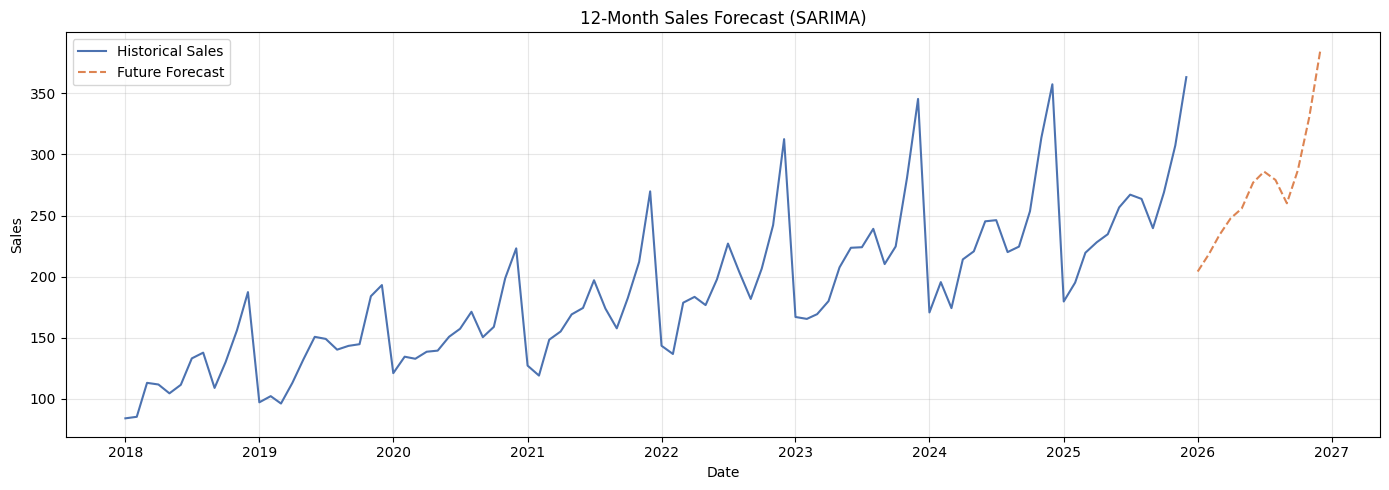

In [29]:
section("Exercise 28: Plot the Final Forecast")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["sales"], label="Historical Sales", color=SINGLE_COLOR)
ax.plot(future["date"], future["forecast_sales"], label="Future Forecast", color=ACCENT_COLOR, linestyle="--")
ax.legend()
ax.set_title("12-Month Sales Forecast (SARIMA)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig("ex28_final_forecast.png", dpi=150)
plt.show()


## Questions

1. **What is the predicted sales for each future month?**

   | Month | Forecast Sales |
   |---|---|
   | Jan 2026 | 204.15 |
   | Feb 2026 | 218.60 |
   | Mar 2026 | 233.96 |
   | Apr 2026 | 247.79 |
   | May 2026 | 255.73 |
   | Jun 2026 | 276.95 |
   | Jul 2026 | 285.96 |
   | Aug 2026 | 279.13 |
   | Sep 2026 | 260.03 |
   | Oct 2026 | 287.14 |
   | Nov 2026 | 330.48 |
   | Dec 2026 | 384.93 |

2. **Which future month has the highest predicted sales?**
   **December 2026**, at approximately 384.9 — consistent with the strongest seasonal factor (1.50) in the original data-generating pattern.

3. **Which future month has the lowest predicted sales?**
   **January 2026**, at approximately 204.2 — consistent with the weakest seasonal factor (0.80).

4. **Can you identify a seasonal pattern in the forecast?**
   Yes — the forecast dips in January, rises fairly steadily through mid-year, dips slightly in September, then climbs sharply through October–December, mirroring the 12-month seasonal_pattern used to generate the data.

5. **Does the forecast make business sense?**
   Yes — it extends the upward trend visible across 2018–2025 while reproducing the same shape of seasonal peaks and troughs seen every prior year, which is exactly the kind of consistent, explainable forecast a retail planner could act on (e.g., staffing and inventory build-up ahead of the November/December peak).


# Part 14: Final Analysis & Synthesis


## Exercise 29: Write Your Conclusions


### A. Decomposition

1. **What trend did you observe?** A steady, roughly linear upward trend across the full 2018–2025 period, rising from about 100 to about 250+.
2. **What seasonal pattern did you observe?** A repeating 12-month cycle, low in January–April, moderate mid-year, and peaking sharply in November–December.
3. **Was additive or multiplicative decomposition more appropriate?** Multiplicative.
4. **Why?** The seasonal swings visibly grow in absolute size as the trend rises — the multiplicative model's ratio-based seasonal component scales with the level, while the additive model's fixed offset cannot, leaving structure in its residual (see Exercises 5–7).


### B. Moving Average

1. **What is a moving average?** The average of a fixed number of consecutive observations, used to smooth out short-term noise and reveal the underlying level or trend.
2. **What happens when the window size increases?** The curve becomes smoother and less responsive to recent changes, since more values are averaged together.
3. **What is the trade-off between smoothing and responsiveness?** A small window responds quickly to real changes but keeps noise; a large window smooths noise (and seasonality) away but lags behind actual turning points.
4. **Which moving average was most useful for understanding the trend?** MA 12 — spanning a full seasonal cycle, it cancels out seasonality entirely and isolates the underlying long-term trend.


### C. Stationarity

1. **Was the original sales series stationary?** No.
2. **How did you determine this?** Visually (rising mean, widening variance), through period-by-period mean/std comparisons (Exercise 9), and confirmed formally with the ADF test (p-value ≈ 0.99, fail to reject H0).
3. **What did differencing do?** Removed the trend, leaving a series that oscillates around zero with a stable mean.
4. **What value of d did you use?** d = 1 — one round of first-order differencing was sufficient to achieve stationarity (ADF p-value dropped to ≈ 0.0000).


### D. ADF

1. **What is the null hypothesis of the ADF test?** H0: the series has a unit root (is non-stationary).
2. **What does a p-value below 0.05 mean?** Reject H0 — the series is stationary.
3. **What does a p-value above 0.05 mean?** Fail to reject H0 — the series is non-stationary.
4. **What was your ADF conclusion before differencing?** Non-stationary (ADF statistic ≈ 0.70, p-value ≈ 0.99).
5. **What was your ADF conclusion after differencing?** Stationary (ADF statistic ≈ -22.79, p-value ≈ 0.0000, well beyond the 1% critical value).


### E. ACF and PACF

1. **What does ACF measure?** The total correlation between the series and its own lagged values, including indirect effects passed through intermediate lags.
2. **What does PACF measure?** The direct correlation between the series and a specific lag, after removing the influence of all shorter intermediate lags.
3. **What is the difference between ACF and PACF?** ACF includes indirect correlation carried through intermediate lags; PACF isolates only the direct relationship with the lag in question.
4. **How did ACF help you select q?** Its early significant lag (lag 1) before dropping toward the confidence band suggested a low-order MA term (q ≈ 1).
5. **How did PACF help you select p?** Its sharp cutoff after lag 1 suggested a low-order AR term (p ≈ 1).
6. **Did you observe seasonal autocorrelation?** Yes — both ACF and PACF showed a clear significant spike at lag 12, confirming a 12-month seasonal dependency that motivated the SARIMA seasonal terms.


### F. ARIMA

1. **What do p, d, and q represent?** p = number of autoregressive (AR) terms, d = number of differences applied, q = number of moving-average (MA) terms.
2. **Which ARIMA model performed best?** ARIMA(2,1,2), among the six candidates tested in Exercise 24.
3. **What were its MAE and RMSE?** MAE ≈ 28.42, RMSE ≈ 42.05.
4. **Did ARIMA capture seasonality well?** No — even the best plain ARIMA configuration substantially underperformed SARIMA, because none of the ARIMA family here includes an explicit seasonal term, so the November/December peak was consistently underestimated.


### G. SARIMA

1. **Why do we use SARIMA?** To explicitly model a recurring seasonal pattern that plain ARIMA cannot represent, by adding seasonal AR, differencing, and MA terms at the seasonal period.
2. **What do P, D, Q, and s represent?** P = seasonal AR order, D = seasonal differencing order, Q = seasonal MA order, s = length of the seasonal cycle (12 for monthly data with yearly seasonality).
3. **Why was s=12 used?** Because the data is monthly and the seasonal cycle repeats every 12 months.
4. **Did SARIMA outperform ARIMA?** Yes, decisively — the best SARIMA (MAE ≈ 10.41, RMSE ≈ 12.49) far outperformed even the best plain ARIMA (MAE ≈ 28.42, RMSE ≈ 42.05).
5. **Why or why not?** The dataset was generated with genuine, strong 12-month seasonality. SARIMA's seasonal terms directly model that structure, while ARIMA can only approximate it indirectly through short non-seasonal lags — which isn't enough to capture a relationship 12 steps apart.


### H. Final Forecast

1. **Which model did you select for the final forecast?** SARIMA(1,1,1)(1,1,1,12), trained on the complete historical dataset.
2. **Why did you select it?** It produced the best out-of-sample MAE and RMSE among all SARIMA candidates tested in Exercise 25, while its AIC was statistically indistinguishable from the top AIC model — making it the strongest choice on the metric that matters most for forecasting: actual predictive accuracy.
3. **What are the predicted sales for the next 12 months?** Ranging from about 204.2 (January 2026, the seasonal low) up to about 384.9 (December 2026, the seasonal high), following the same rise-dip-surge shape seen in every prior year of the historical data.
4. **What business decisions could be made using these forecasts?** Planning inventory and staffing levels ahead of the October–December demand surge, budgeting conservatively around the January–February trough, and using the forecast as a baseline against which to measure the incremental effect of future promotions.


# Part 15: Quick Reference Sheet


**Moving Average**
- Smooths short-term fluctuations.
- Small window → more responsive, more noise.
- Large window → more smoothing, less responsive.

**Additive vs Multiplicative Decomposition**
- Additive: `Observed = Trend + Seasonality + Residual` — use when seasonal fluctuations are approximately constant in size.
- Multiplicative: `Observed = Trend x Seasonality x Residual` — use when seasonal fluctuations grow with the level of the series.

**Stationarity & ADF Test**
- A stationary series has a relatively stable mean, variance, and autocorrelation structure over time.
- H0: unit root exists → non-stationary. H1: no unit root → stationary.
- p < 0.05 → Reject H0 → Stationary.
- p > 0.05 → Fail to reject H0 → Non-stationary.

**ACF & PACF Diagnostics**
- ACF (Autocorrelation Function): total correlation with previous lags, including indirect effects — helps identify candidate MA(q) terms.
- PACF (Partial Autocorrelation Function): direct correlation with a lag after removing intermediate lags — helps identify candidate AR(p) terms.

**ARIMA & SARIMA Specifications**
- ARIMA(p, d, q): p = AR order, d = differencing order, q = MA order.
- SARIMA(p, d, q)(P, D, Q, s): non-seasonal (p, d, q) plus seasonal (P, D, Q) at seasonal period s (s = 12 for monthly data with yearly seasonality).

**This Lab's Key Results**
| Model | MAE | RMSE |
|---|---|---|
| ARIMA(1,1,1) baseline | 43.20 | 57.55 |
| Best ARIMA — (2,1,2) | 28.42 | 42.05 |
| SARIMA(1,1,1)(1,1,1,12) — selected final model | 10.41 | 12.49 |

SARIMA's explicit seasonal terms were decisive for this dataset's strong 12-month seasonal pattern, cutting RMSE by roughly 78% relative to the ARIMA(1,1,1) baseline.
